# Subsample BCN Noise ML Dataset

This notebook creates a smaller version of `bcn_noise_ml_dataset.csv` and exports it as a new CSV.

The goal is to keep the reduced dataset representative of the full one. Because each street has three noise values (`noise_day`, `noise_evening`, `noise_night`), we first compress them into a single row-level exposure score and then sample evenly across noise ranges.

That gives us a simpler and more stable notion of “noise bucket” than trying to sample independently on three correlated targets.

## Why this bucketing strategy?

The three noise columns are measured on the same street segment and move together, so treating them as three separate sampling axes would make the selection rule harder to interpret and more brittle.

Instead, we build one summary score per row and bucket that score:

1. `noise_score = mean(noise_day, noise_evening, noise_night)` keeps the overall exposure level of the street.
2. `pd.qcut(...)` creates buckets with roughly equal numbers of rows, which avoids one noise range dominating the sample.
3. Sampling `50%` inside each bucket keeps the final dataset balanced while cutting the total size in half.

If you want a stricter definition of exposure, you can replace the mean with the maximum noise value. The mean is a better default here because it reflects the typical exposure across the day, evening, and night without overweighting a single peak period.

In [2]:
import pandas as pd
from pathlib import Path

# Keep the split reproducible so the same rows are selected every time.
RANDOM_STATE = 42
INPUT_PATH = Path('../../data/machine_learning/bcn_noise_ml_dataset.csv')
OUTPUT_PATH = Path('../../data/machine_learning/bcn_noise_ml_dataset_halved.csv')
NOISE_COLUMNS = ['noise_day', 'noise_evening', 'noise_night']

# Eight buckets is a practical compromise:
# - enough resolution to separate quieter and louder streets
# - still enough rows per bucket to sample 50% safely
N_BUCKETS = 8
SAMPLE_FRACTION = 0.5

print(f'Input: {INPUT_PATH}')
print(f'Output: {OUTPUT_PATH}')

Input: ..\..\data\machine_learning\bcn_noise_ml_dataset.csv
Output: ..\..\data\machine_learning\bcn_noise_ml_dataset_halved.csv


In [3]:
df = pd.read_csv(INPUT_PATH)

missing_columns = [column for column in NOISE_COLUMNS if column not in df.columns]
if missing_columns:
    raise ValueError(f'Missing noise columns: {missing_columns}')

# Work on a copy so the original input frame stays untouched.
df = df.copy()

# Collapse the three time-of-day measures into one representative exposure score.
# Mean is the default because it captures the overall noise level of the street.
df['noise_score'] = df[NOISE_COLUMNS].mean(axis=1)

# Quantile buckets give roughly equal-sized groups, which is exactly what we want
# before taking the same sampling fraction from each group.
df['noise_bucket'] = pd.qcut(
    df['noise_score'],
    q=N_BUCKETS,
    labels=False,
    duplicates='drop'
)

bucket_counts = df['noise_bucket'].value_counts(dropna=False).sort_index()
display(bucket_counts.to_frame(name='rows_in_bucket'))
print(f'Original rows: {len(df)}')
print(f"Buckets created: {df['noise_bucket'].nunique(dropna=True)}")

,rows_in_bucket
noise_bucket,
0,3049
1,1410
2,2391
3,1796
4,2462
5,1631
6,2084
7,1949


Original rows: 16772
Buckets created: 8


In [4]:
sampled_with_helpers = (
    # Keep the bucket label during the groupby/apply step so we can inspect balance later.
    df.dropna(subset=['noise_bucket'])
      .groupby('noise_bucket', group_keys=True)
      .apply(lambda bucket: bucket.sample(frac=SAMPLE_FRACTION, random_state=RANDOM_STATE))
      .reset_index(level=0)
      .sort_index()
      .reset_index(drop=True)
)

sampled_bucket_counts = sampled_with_helpers['noise_bucket'].value_counts().sort_index()
display(sampled_bucket_counts.to_frame(name='sampled_rows'))
print(f'Sampled rows: {len(sampled_with_helpers)}')
print(f'Sampled share: {len(sampled_with_helpers) / len(df):.2%}')

# Drop the temporary helper columns before exporting the final dataset.
sampled_df = sampled_with_helpers.drop(columns=['noise_score', 'noise_bucket'])
if 'fid' in sampled_df.columns:
    sampled_df = sampled_df.sort_values('fid').reset_index(drop=True)
else:
    sampled_df = sampled_df.reset_index(drop=True)

display(sampled_df.head())

,sampled_rows
noise_bucket,
0,1524
1,705
2,1196
3,898
4,1231
5,816
6,1042
7,974


Sampled rows: 8386
Sampled share: 50.00%


,street_id,noise_day,noise_evening,noise_night,road_length,road_category,one_way,distance_to_road,fid,osm_commercial_pct_50m,...,support_infrastructure_count_per_meter_150m,street_tree_count_10m,park_tree_count_10m,street_tree_count_20m,park_tree_count_20m,total_tree_count_10m,total_tree_count_20m,road_width,openness,edge_betweenness
0,T05360P,55,55,50,91.759758,5,1,0.0,5,0.0,...,0.000000,1,0,11,0,1,11,15.404320,0.454545,0.000943
1,T08863T,50,50,45,86.869284,5,1,0.0,6,0.0,...,0.023023,1,0,2,0,1,2,9.382715,0.200000,0.001085
2,T13009A,55,55,50,147.700343,5,1,0.0,8,0.0,...,0.020311,0,0,1,0,0,1,36.722212,0.710526,0.003190
3,T16868V,45,45,40,153.250633,5,1,0.0,10,0.0,...,0.006525,10,0,11,0,10,11,33.145383,0.675000,0.000834
4,T04571U,60,55,50,94.090297,5,1,0.0,12,0.0,...,0.000000,9,0,13,0,9,13,30.479123,0.590909,0.001827


In [5]:
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
sampled_df.to_csv(OUTPUT_PATH, index=False)

print(f'Exported {len(sampled_df)} rows to: {OUTPUT_PATH}')

Exported 8386 rows to: ..\..\data\machine_learning\bcn_noise_ml_dataset_halved.csv


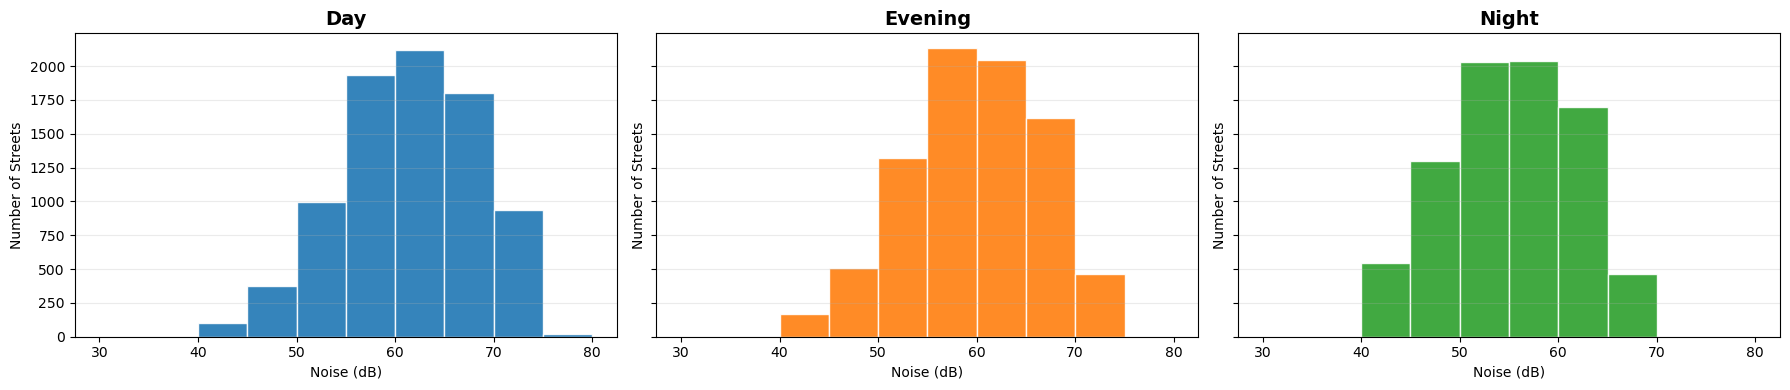

Saved histogram figure to: ..\..\figures\subsampled_noise_histograms.png


OSError: 'seaborn-whitegrid' is not a valid package style, path of style file, URL of style file, or library style name (library styles are listed in `style.available`)

In [ ]:
# Visualize the halved dataset with the same grouped style as the reference figure.
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

if 'sampled_df' not in globals():
    sampled_df = pd.read_csv(OUTPUT_PATH)

fig_dir = Path('../../figures')
fig_dir.mkdir(parents=True, exist_ok=True)

bins = [0, 40, 45, 50, 55, 60, 65, 70, 75, 80]
labels = ["0 - 40 dB(A)", "40 - 45 dB(A)", "45 - 50 dB(A)", "50 - 55 dB(A)", "55 - 60 dB(A)", "60 - 65 dB(A)", "65 - 70 dB(A)", "70 - 75 dB(A)", "75 - 80 dB(A)"]
periods = [("noise_day", "Day", "#1f77b4"), ("noise_evening", "Evening", "#ff7f0e"), ("noise_night", "Night", "#2ca02c")]

plot_df = sampled_df.copy()
for col, _, _ in periods:
    if plot_df[col].dtype == object:
        plot_df[col] = pd.to_numeric(plot_df[col], errors='coerce')

# 1) Side-by-side histograms for the three target columns.
fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)
for ax, (col, title, color) in zip(axes, periods):
    ax.hist(plot_df[col].dropna(), bins=np.arange(30, 85, 5), color=color, edgecolor='white', alpha=0.9)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Noise (dB)')
    ax.set_ylabel('Number of Streets')
    ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
hist_path = fig_dir / 'subsampled_noise_histograms.png'
fig.savefig(hist_path, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved histogram figure to: {hist_path}')

# 2) Grouped bar chart by noise bucket, matching the original style.
for col, _, _ in periods:
    plot_df[f'{col}_bucket'] = pd.cut(plot_df[col].astype(float), bins=bins, labels=labels, right=False)
day_counts = plot_df['noise_day_bucket'].value_counts().reindex(labels, fill_value=0)
evening_counts = plot_df['noise_evening_bucket'].value_counts().reindex(labels, fill_value=0)
night_counts = plot_df['noise_night_bucket'].value_counts().reindex(labels, fill_value=0)

x = np.arange(len(labels))
width = 0.25
fig, ax = plt.subplots(figsize=(16, 6))
ax.bar(x - width, day_counts.values, width=width, label='Day', color='#1f77b4')
ax.bar(x, evening_counts.values, width=width, label='Evening', color='#ff7f0e')
ax.bar(x + width, night_counts.values, width=width, label='Night', color='#2ca02c')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=30, ha='right')
ax.set_ylabel('Number of Streets')
ax.set_xlabel('Noise Level (dB)')
ax.set_title('Number of Streets by Noise Level (Day, Evening, Night)', fontsize=18, fontweight='bold')
leg = ax.legend(title='Period', fontsize=11, title_fontsize=11, loc='upper right', frameon=True)
leg.get_frame().set_edgecolor('0.2')
leg.get_frame().set_alpha(0.95)
ax.yaxis.grid(True, color='gray', linestyle='--', linewidth=0.5, alpha=0.3)
ax.xaxis.grid(False)
ax.set_axisbelow(True)
plt.tight_layout()
bar_path = fig_dir / 'subsampled_noise_buckets.png'
fig.savefig(bar_path, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved grouped bar chart to: {bar_path}')